# 1.1 Load and inspect a single TCX file

Before processing all activities, load one TCX file to verify that:

- the parser correctly extracts distance, heart rate, and cadence  
- speed and pace are computed correctly  
- the time index is continuous and sorted  
- no values are missing or obviously wrong

`df.head()` shows the first few seconds of the run, and  
`.describe()` summarises the main time-series variables to check their ranges and ensure the raw data looks correct before extracting features.

In [18]:
from parse_tcx import parse_tcx

df = parse_tcx("../data/raw/activity_20401950071.tcx")
print(df.head())
print(df[["speed_mps", "pace_s_per_km", "hr", "cadence"]].describe())

                                               time    hr  cadence  \
time                                                                 
2025-09-16 10:11:45+00:00 2025-09-16 10:11:45+00:00  83.0     58.0   
2025-09-16 10:11:46+00:00 2025-09-16 10:11:46+00:00  84.0     58.0   
2025-09-16 10:11:47+00:00 2025-09-16 10:11:47+00:00  84.0     58.0   
2025-09-16 10:11:48+00:00 2025-09-16 10:11:48+00:00  85.0     58.0   
2025-09-16 10:11:49+00:00 2025-09-16 10:11:49+00:00  86.0     58.0   

                           distance_m  speed_mps     elev_m  elapsed_s  \
time                                                                     
2025-09-16 10:11:45+00:00        2.91      0.504  21.000000        0.0   
2025-09-16 10:11:46+00:00        4.85      1.372  21.000000        1.0   
2025-09-16 10:11:47+00:00        4.97      1.064  21.000000        2.0   
2025-09-16 10:11:48+00:00        5.99      0.942  20.799999        3.0   
2025-09-16 10:11:49+00:00        6.94      0.942  20.600000      

# 1.2 Resample run to 1 Hz and compute features for one activity

Take the raw TCX data for a single run and pass it through the feature pipeline:

1. `parse_tcx(...)` loads the original time series (distance, HR, cadence, speed, pace).
2. `resample_to_1s(df_raw)` converts it to a clean 1-second grid and recomputes pace/speed.
3. `compute_early_late_features(df_1s)` splits the run into early and late segments (first/last 30%) and calculates:
   - mean, standard deviation, and coefficient of variation for pace, HR, and cadence  
   - drift metrics (late mean – early mean).
4. `compute_surge_features(df_1s)` counts how many “pace surges” (large speed changes) occur over the whole run and specifically in the late segment.

The output (`early_late_feats`, `surge_feats`) is a compact feature vector describing how pacing, HR, and cadence behave and how erratic the pacing becomes as fatigue builds in this single run.

In [19]:
from pathlib import Path
from parse_tcx import parse_tcx
from features import (
    resample_to_1s,
    compute_early_late_features,
    compute_surge_features,
    compute_terrain_features,
    compute_neuro_features,
)


fp = Path("../data/raw/activity_20401950071.tcx")  # or whichever file
df_raw = parse_tcx(fp)
df_1s = resample_to_1s(df_raw)

early_late_feats = compute_early_late_features(df_1s)
surge_feats = compute_surge_features(df_1s)

early_late_feats, surge_feats

/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()


({'early_hr_mean': 145.19573901464713,
  'late_hr_mean': 152.30093209054593,
  'hr_mean_drift': 7.1051930758987965,
  'early_pace_s_per_km_mean': 348.71213256320686,
  'late_pace_s_per_km_mean': 360.1688437836151,
  'pace_s_per_km_mean_drift': 11.456711220408238,
  'pace_cv_early': 0.22374874576421938,
  'pace_cv_late': 0.029145522485091866,
  'pace_cv_ratio': 0.1302600485448292,
  'cadence_cv_early': 0.11900035204605905,
  'cadence_cv_late': 0.07398391224621353,
  'cadence_cv_ratio': 0.6217117090340882,
  'flat_hr_mean_drift': 5.9227528089887755,
  'flat_pace_mean_drift': 6.5606007694021855},
 {'surges_all_10s_8pct': 105, 'surges_late_10s_8pct': 12})

# 1.3 Build the full feature table for all TCX files

Loop through every TCX file in `data/raw` and run the complete feature extraction pipeline:

1. **Load raw file** → `parse_tcx(fp)`  
2. **Resample to 1 Hz** → `resample_to_1s(df_raw)`  
3. **Compute early/late metrics** → pacing, HR, cadence drift and CV  
4. **Compute surge metrics** → total surges and late-segment surges  
5. Store all outputs in a dictionary representing one run  
6. Append to `all_runs`

After processing all activities, convert the list of dictionaries into a DataFrame:

- Each row = one run  
- Columns = all early/late stats and surge counts  
- `features_df.describe()` provides a quick check of value ranges and missing data

In [30]:
import pandas as pd
from pathlib import Path
from parse_tcx import parse_tcx
from features import (
    resample_to_1s,
    compute_early_late_features,
    compute_surge_features,
    compute_terrain_features,
    compute_neuro_features,
)

data_dir = Path("../data/raw")
files = list(data_dir.glob("*.tcx"))
print("Found files:", len(files))

all_runs = []

for fp in files:
    # 1. load raw TCX
    df_raw = parse_tcx(fp)

    # 2. resample to 1 Hz (adds terrain columns, elapsed_s, etc.)
    df_1s = resample_to_1s(df_raw)

    # basic metadata for this run
    run_start = df_raw["time"].iloc[0]

    feats = {
        "file": fp.name,
        "start_time": run_start,
    }

    # 3. early/late fatigue metrics
    feats.update(compute_early_late_features(df_1s))

    # 4. surge metrics
    feats.update(compute_surge_features(df_1s))


    # 5. terrain metrics
    feats.update(compute_terrain_features(df_1s))

    # 6. neuro / control / session-summary metrics
    feats.update(compute_neuro_features(df_1s))
    from features import compute_interval_pattern_features

    feats.update(compute_interval_pattern_features(df_1s))

    all_runs.append(feats)

# build final feature table
features_df = (
    pd.DataFrame(all_runs)
    .sort_values("start_time")
    .reset_index(drop=True)
)

print("Feature table shape:", features_df.shape)
display(features_df)   
features_df.describe(include="all")


Found files: 20


/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = d

Feature table shape: (20, 40)


/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()


,file,start_time,early_hr_mean,late_hr_mean,hr_mean_drift,early_pace_s_per_km_mean,late_pace_s_per_km_mean,pace_s_per_km_mean_drift,pace_cv_early,pace_cv_late,...,warmup_stab_time_s,finish_collapse_pct,hr_recovery_10s_mean,hr_std_60s_mean,duration_min,mean_hr,pace_cv_run,interval_on_count,interval_off_count,interval_patterns_consistent
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,145.195739,152.300932,7.105193,348.712133,360.168844,11.456711,0.223749,0.029146,...,1200.0,2.891601,-2.300000,2.770703,41.666667,151.671731,0.136569,0,2,False
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,153.056675,175.006297,21.949622,343.230323,321.152027,-22.078296,0.070032,0.126631,...,1200.0,12.033737,-4.642857,2.209818,44.100000,166.474122,0.103629,2,2,False
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,160.698157,159.669355,-1.028802,355.274019,356.782885,1.508866,0.206449,0.142299,...,1200.0,8.056690,-1.666667,2.663730,48.183333,161.442254,0.167286,0,3,False
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,151.807692,168.937666,17.129973,367.206760,355.725325,-11.481434,0.129237,0.166619,...,1200.0,-6.879273,-0.280769,2.742452,41.833333,160.115890,0.157340,4,4,True
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,168.785582,189.724584,20.939002,431.728184,440.319278,8.591095,1.075420,0.689920,...,1200.0,-47.718637,0.853659,4.626893,30.016667,179.195893,0.835347,0,6,False
5,activity_20566587122.tcx,2025-10-02 08:55:09+00:00,155.032143,157.703571,2.671429,385.650568,391.871820,6.221252,0.240160,0.272220,...,1200.0,3.759236,-0.850000,2.763947,54.416667,155.356399,0.212860,1,7,False
6,activity_20579970564.tcx,2025-10-03 17:42:48+00:00,167.203991,187.487805,20.283814,291.685707,434.700640,143.014933,0.224681,0.990168,...,1070.0,44.079091,-0.041667,2.790070,25.000000,182.359760,0.751969,0,4,False
7,activity_20584569891.tcx,2025-10-04 09:15:01+00:00,146.768621,156.125198,9.356577,437.863398,400.484202,-37.379195,0.613423,0.033316,...,1200.0,2.046207,-0.774194,2.058968,35.016667,152.421503,0.364123,1,2,False
8,activity_20595800285.tcx,2025-10-05 10:29:40+00:00,160.645601,173.859665,13.214064,368.685216,335.579298,-33.105919,0.269034,0.108966,...,1200.0,-20.574066,-1.400000,3.261619,89.650000,166.637268,0.296878,2,16,False
9,activity_20603961785.tcx,2025-10-06 09:13:25+00:00,149.976488,164.144914,14.168426,387.961370,381.371478,-6.589892,0.125253,0.155310,...,1200.0,-12.221407,-1.785714,3.172328,57.866667,156.867118,0.243409,5,5,False


,file,start_time,early_hr_mean,late_hr_mean,hr_mean_drift,early_pace_s_per_km_mean,late_pace_s_per_km_mean,pace_s_per_km_mean_drift,pace_cv_early,pace_cv_late,...,warmup_stab_time_s,finish_collapse_pct,hr_recovery_10s_mean,hr_std_60s_mean,duration_min,mean_hr,pace_cv_run,interval_on_count,interval_off_count,interval_patterns_consistent
count,20,20,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20
unique,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,activity_20401950071.tcx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18
mean,NaN,2025-10-06 15:58:12.799999744+00:00,157.016131,170.931574,13.915443,371.733911,387.805220,16.071308,0.286118,0.296218,...,1126.00000,-0.592897,-2.087168,3.175450,47.329167,165.056903,0.297944,2.050000,5.100000,NaN
min,NaN,2025-09-16 10:11:45+00:00,142.970501,152.300932,-1.028802,254.427168,269.224588,-37.379195,0.053443,0.019062,...,810.00000,-47.718637,-10.500000,1.225702,16.016667,151.671731,0.049892,0.000000,0.000000,NaN
25%,NaN,2025-10-01 23:06:24+00:00,151.025746,159.503847,8.316806,341.075776,350.688818,-13.452289,0.116485,0.080812,...,1167.50000,-6.438721,-2.548039,2.329546,34.108333,155.701267,0.102938,0.000000,2.000000,NaN
50%,NaN,2025-10-07 01:25:24+00:00,154.044409,169.229142,14.452751,367.946454,382.309332,4.459868,0.183451,0.148804,...,1200.00000,-1.280179,-1.726190,2.775639,41.775000,160.779072,0.162313,1.000000,4.000000,NaN
75%,NaN,2025-10-12 17:20:34.750000128+00:00,163.040607,180.976550,20.447611,398.971210,423.100725,15.107938,0.290165,0.362233,...,1200.00000,4.087726,-0.831048,3.283402,54.925000,172.624107,0.381229,2.500000,6.250000,NaN
max,NaN,2025-11-01 11:52:58+00:00,179.629238,194.688654,25.279823,482.858631,651.884585,169.025953,1.075420,1.179273,...,1200.00000,44.079091,3.500000,7.947994,99.900000,187.926856,1.046147,15.000000,16.000000,NaN


# 2.1 Building Fatigue Scores (CML & GPV)

This section transforms the raw run-level features into two core fatigue metrics:

### 1. Derived Ratios
We compute three ratios that express how much *variability or instability* increases from the early part of the run to the late part:

- **pace_cv_ratio**  
  = late pace CV / early pace CV  
  → how much pacing variability worsened under fatigue

- **cadence_cv_ratio**  
  = late cadence CV / early cadence CV  
  → whether the runner struggled to maintain a stable rhythm

- **surge_ratio**  
  = late surges / total surges  
  → whether pacing becomes more erratic later in the run

We also clean infinities (e.g., if the early CV was zero).

---

### 2. Z-Scoring (Normalization)
All fatigue-relevant variables are converted to **z-scores within your dataset**, so that:

- 0 = average for your runs  
- +1 = 1 standard deviation above your norm (higher fatigue signal)  
- –1 = 1 standard deviation below your norm (lower fatigue signal)

Z-scored variables:
- hr_mean_drift  
- late_hr_mean  
- pace_mean_drift  
- pace_cv_ratio  
- cadence_cv_ratio  
- surge_ratio

---

### 3. Building Composite Fatigue Metrics

#### **Cardio-Metabolic Load (CML_z)**
A composite score reflecting **systemic/physiological load**, combining:
- heart rate drift (strongest contributor)
- late HR level
- pace drift

High CML_z = your *cardio + muscular system* was taxed heavily.

#### **Gait/Pacing Variability (GPV_z)**
A composite score reflecting **coordination, stability, and pacing control**, combining:
- worsening pace variability
- worsening cadence variability
- more late surges

High GPV_z = pacing and mechanics became more unstable.

---

### 4. What These Two Scores Mean

- **CML_z ↑**  
  → more physiological strain (peripheral fatigue: legs/body limitations)

- **GPV_z ↑**  
  → more instability/noise in pacing (central/regulation fatigue: focus/coordination issues)

These two scores form the foundation of the **four-quadrant fatigue classification**:

| Low GPV | High GPV |
|--------|----------|
| **Low CML → Type D (Fresh)** | **Type B (Regulation-Limited)** |
| **High CML → Type A (Body-Limited)** | **Type C (Global Fatigue)** |

In [31]:
from features import compute_cml_gpv_scores

features_df = compute_cml_gpv_scores(features_df)
display(features_df[["file", "CML_z", "GPV_z"]].head())

,file,CML_z,GPV_z
0,activity_20401950071.tcx,-1.510109,-2.411931
1,activity_20411248791.tcx,1.121684,1.407965
2,activity_20432446314.tcx,-2.341365,0.003414
3,activity_20535336288.tcx,0.037698,-0.083148
4,activity_20549513473.tcx,1.022311,0.373967


# 2.2 Interpreting the CML_z and GPV_z Summary Table

This table shows the statistical distribution (count, mean, std, min, percentiles, max) for:
- **CML_z** (systemic load)
- **GPV_z** (pacing variability)

### What each value represents

- **count**  
  Number of runs that were processed.

- **mean**  
  Should be ~0 because these are z-scores.

- **std**  
  Should be ~1 (by definition of z-score).

- **min / max**  
  The lowest/highest fatigue scores relative to your own dataset.

- **25%, 50%, 75% (quartiles)**  
  Show where the middle of your distribution lies:
  - values above 0 → above-average fatigue signal  
  - values below 0 → lower-than-average fatigue signal

### How to read CML_z

- **High CML_z (positive)**  
  → big HR drift, high late HR, large pace slowdown  
  → “body-limited” or systemic fatigue

- **Low CML_z (negative)**  
  → minimal physical load  
  → fresh / controlled / easy run

### How to read GPV_z

- **High GPV_z (positive)**  
  → unstable pacing/cadence, lots of late surges  
  → “regulation-limited” or unstable coordination/focus

- **Low GPV_z (negative)**  
  → smooth, consistent pacing and rhythm  
  → fresh or controlled mechanics

These two distributions help validate whether your dataset has variance and whether the CML/GPV scores behave as expected.

In [32]:
features_df[["CML_z", "GPV_z"]].describe()


,CML_z,GPV_z
count,20.000000,2.000000e+01
mean,-0.051958,2.331468e-16
std,1.676320,1.766453e+00
min,-2.677805,-3.283103e+00
25%,-1.377007,-1.287277e+00
50%,-0.252574,-2.405555e-02
75%,1.058048,1.225157e+00
max,3.769072,4.244464e+00


# 2.3 Session type detection (auto + manual override)

In [34]:
import pandas as pd
from pathlib import Path
from parse_tcx import parse_tcx
from features import (
    resample_to_1s,
    compute_early_late_features,
    compute_surge_features,
    compute_terrain_features,
    compute_neuro_features,
    compute_interval_pattern_features,
    #compute_hr_zone_features,  
)

data_dir = Path("../data/raw")
files = list(data_dir.glob("*.tcx"))
print("Found files:", len(files))

all_runs = []

for fp in files:
    # 1. load raw TCX
    df_raw = parse_tcx(fp)

    # 2. resample to 1 Hz (adds terrain columns, elapsed_s, etc.)
    df_1s = resample_to_1s(df_raw)

    # basic metadata for this run
    run_start = df_raw["time"].iloc[0]

    feats = {
        "file": fp.name,
        "start_time": run_start,
    }

    feats.update(compute_early_late_features(df_1s))
    feats.update(compute_surge_features(df_1s))
    feats.update(compute_terrain_features(df_1s))
    feats.update(compute_neuro_features(df_1s))
    feats.update(compute_interval_pattern_features(df_1s))
    #feats.update(compute_hr_zone_features(df_1s))

    # 3. early/late fatigue metrics
    feats.update(compute_early_late_features(df_1s))

    # 4. surge metrics
    feats.update(compute_surge_features(df_1s))

    # 5. terrain metrics
    feats.update(compute_terrain_features(df_1s))

    # 6. neuro / control / session-summary metrics
    feats.update(compute_neuro_features(df_1s))

    # 7. interval pattern metrics (NEW)
    feats.update(compute_interval_pattern_features(df_1s))

    all_runs.append(feats)

# build final feature table
features_df = (
    pd.DataFrame(all_runs)
    .sort_values("start_time")
    .reset_index(drop=True)
)

print("Feature table shape:", features_df.shape)
display(features_df)   
features_df.describe(include="all")


Found files: 20


/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()
/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = d

Feature table shape: (20, 40)


/Users/hanna/Documents/GitHub/fatigue-detector/src/features.py:31: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_1s = df[cols].resample("1S").mean()


,file,start_time,early_hr_mean,late_hr_mean,hr_mean_drift,early_pace_s_per_km_mean,late_pace_s_per_km_mean,pace_s_per_km_mean_drift,pace_cv_early,pace_cv_late,...,warmup_stab_time_s,finish_collapse_pct,hr_recovery_10s_mean,hr_std_60s_mean,duration_min,mean_hr,pace_cv_run,interval_on_count,interval_off_count,interval_patterns_consistent
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,145.195739,152.300932,7.105193,348.712133,360.168844,11.456711,0.223749,0.029146,...,1200.0,2.891601,-2.300000,2.770703,41.666667,151.671731,0.136569,0,2,False
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,153.056675,175.006297,21.949622,343.230323,321.152027,-22.078296,0.070032,0.126631,...,1200.0,12.033737,-4.642857,2.209818,44.100000,166.474122,0.103629,2,2,False
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,160.698157,159.669355,-1.028802,355.274019,356.782885,1.508866,0.206449,0.142299,...,1200.0,8.056690,-1.666667,2.663730,48.183333,161.442254,0.167286,0,3,False
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,151.807692,168.937666,17.129973,367.206760,355.725325,-11.481434,0.129237,0.166619,...,1200.0,-6.879273,-0.280769,2.742452,41.833333,160.115890,0.157340,4,4,True
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,168.785582,189.724584,20.939002,431.728184,440.319278,8.591095,1.075420,0.689920,...,1200.0,-47.718637,0.853659,4.626893,30.016667,179.195893,0.835347,0,6,False
5,activity_20566587122.tcx,2025-10-02 08:55:09+00:00,155.032143,157.703571,2.671429,385.650568,391.871820,6.221252,0.240160,0.272220,...,1200.0,3.759236,-0.850000,2.763947,54.416667,155.356399,0.212860,1,7,False
6,activity_20579970564.tcx,2025-10-03 17:42:48+00:00,167.203991,187.487805,20.283814,291.685707,434.700640,143.014933,0.224681,0.990168,...,1070.0,44.079091,-0.041667,2.790070,25.000000,182.359760,0.751969,0,4,False
7,activity_20584569891.tcx,2025-10-04 09:15:01+00:00,146.768621,156.125198,9.356577,437.863398,400.484202,-37.379195,0.613423,0.033316,...,1200.0,2.046207,-0.774194,2.058968,35.016667,152.421503,0.364123,1,2,False
8,activity_20595800285.tcx,2025-10-05 10:29:40+00:00,160.645601,173.859665,13.214064,368.685216,335.579298,-33.105919,0.269034,0.108966,...,1200.0,-20.574066,-1.400000,3.261619,89.650000,166.637268,0.296878,2,16,False
9,activity_20603961785.tcx,2025-10-06 09:13:25+00:00,149.976488,164.144914,14.168426,387.961370,381.371478,-6.589892,0.125253,0.155310,...,1200.0,-12.221407,-1.785714,3.172328,57.866667,156.867118,0.243409,5,5,False


,file,start_time,early_hr_mean,late_hr_mean,hr_mean_drift,early_pace_s_per_km_mean,late_pace_s_per_km_mean,pace_s_per_km_mean_drift,pace_cv_early,pace_cv_late,...,warmup_stab_time_s,finish_collapse_pct,hr_recovery_10s_mean,hr_std_60s_mean,duration_min,mean_hr,pace_cv_run,interval_on_count,interval_off_count,interval_patterns_consistent
count,20,20,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.00000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20
unique,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,activity_20401950071.tcx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18
mean,NaN,2025-10-06 15:58:12.799999744+00:00,157.016131,170.931574,13.915443,371.733911,387.805220,16.071308,0.286118,0.296218,...,1126.00000,-0.592897,-2.087168,3.175450,47.329167,165.056903,0.297944,2.050000,5.100000,NaN
min,NaN,2025-09-16 10:11:45+00:00,142.970501,152.300932,-1.028802,254.427168,269.224588,-37.379195,0.053443,0.019062,...,810.00000,-47.718637,-10.500000,1.225702,16.016667,151.671731,0.049892,0.000000,0.000000,NaN
25%,NaN,2025-10-01 23:06:24+00:00,151.025746,159.503847,8.316806,341.075776,350.688818,-13.452289,0.116485,0.080812,...,1167.50000,-6.438721,-2.548039,2.329546,34.108333,155.701267,0.102938,0.000000,2.000000,NaN
50%,NaN,2025-10-07 01:25:24+00:00,154.044409,169.229142,14.452751,367.946454,382.309332,4.459868,0.183451,0.148804,...,1200.00000,-1.280179,-1.726190,2.775639,41.775000,160.779072,0.162313,1.000000,4.000000,NaN
75%,NaN,2025-10-12 17:20:34.750000128+00:00,163.040607,180.976550,20.447611,398.971210,423.100725,15.107938,0.290165,0.362233,...,1200.00000,4.087726,-0.831048,3.283402,54.925000,172.624107,0.381229,2.500000,6.250000,NaN
max,NaN,2025-11-01 11:52:58+00:00,179.629238,194.688654,25.279823,482.858631,651.884585,169.025953,1.075420,1.179273,...,1200.00000,44.079091,3.500000,7.947994,99.900000,187.926856,1.046147,15.000000,16.000000,NaN


# 2.4 Interpreting the CML_z and GPV_z Summary Table

Neuro-Tagging (Optional User Self-Report Layer)
This section lets me add manual labels describing how the run felt (“legs heavy”, “felt fine”, “mentally tired”), so the classifier can combine objective data (CML & GPV) with subjective neuro-fatigue signals.
I create a dictionary (neuro_map) mapping a file name → a neuro state.
Then I add a new column neuro_tag to the feature table.
Runs not included in the dictionary stay as "none".
This is optional and can be expanded later as I manually annotate more activities.

In [35]:
# Optional neuro-tagging (manual labels for now)
neuro_map = {
    "activity_20432446314.tcx": "body_limited",
    "activity_20401950071.tcx": "fresh",
    # add more labels here as you annotate runs
}

features_df["neuro_tag"] = features_df["file"].map(neuro_map).fillna("none")

features_df[["file", "neuro_tag"]].head()


,file,neuro_tag
0,activity_20401950071.tcx,fresh
1,activity_20411248791.tcx,none
2,activity_20432446314.tcx,body_limited
3,activity_20535336288.tcx,none
4,activity_20549513473.tcx,none


# 2.5 Applying the classifier (fixing the neuro_tag overlap)

`features_df` already contains a `neuro_tag` column from the manual labelling step.  
When I first joined the classifier outputs back onto `features_df`, the result of
`apply_classifier` also contained a `neuro_tag` column, so Pandas raised:

> `ValueError: columns overlap but no suffix specified`

To fix this, I:
- keep `neuro_tag` only in `features_df`
- **do not** return `neuro_tag` from `apply_classifier`
- compute the extra columns in a separate DataFrame and then join it back.


In [36]:
import numpy as np
import pandas as pd

def infer_session_type(row) -> str:
    """
    Heuristic session-type classifier using:
    - HR zone fractions (Z3/Z4/Z5)
    - surges per km (pace surges)
    - duration & distance
    - CML_phys_z (overall load)
    """

    dur = row.get("duration_min", np.nan)
    dist = row.get("total_distance_km", np.nan)
    cml = row.get("CML_phys_z", np.nan)
    pace_cv_run = row.get("pace_cv_run", np.nan)
    surges = row.get("surges_all_10s_8pct", np.nan)

    # HR zones (fractions of time in each)
    z3 = row.get("time_in_z3_frac", np.nan)
    z4 = row.get("time_in_z4_frac", np.nan)
    z5 = row.get("time_in_z5_frac", np.nan)

    # combined high-intensity fraction
    z45 = (0 if pd.isna(z4) else z4) + (0 if pd.isna(z5) else z5)

    # surges per km as “how choppy is this run?”
    surges_per_km = np.nan
    if not pd.isna(surges) and not pd.isna(dist) and dist > 0:
        surges_per_km = surges / dist

    # ---------------------------
    # 0. Basic sanity
    # ---------------------------
    if pd.isna(dur) or dur <= 0:
        return "easy"

    # ---------------------------
    # 1. INTERVALS
    # ---------------------------
    # Idea:
    #   - lots of surges per km (pace changing up/down a lot),
    #   - moderate-high time in Z4+Z5 (but not 90%+ like a pure race),
    #   - typical duration range for your interval sessions.
    #
    if (
        20 <= dur <= 80
        and (not pd.isna(surges_per_km) and surges_per_km >= 1.5)
        and (not pd.isna(z45) and 0.20 <= z45 <= 0.80)
    ):
        return "interval"

    # ---------------------------
    # 2. RACE
    # ---------------------------
    # Idea:
    #   - large chunk of time in Z4+Z5,
    #   - relatively continuous (few surges needed),
    #   - strong physiological drift (CML_phys_z high),
    #   - either 5–10k style (shorter distance) or HM style (15km+).
    #
    if (
        not pd.isna(z45) and z45 >= 0.50
        and 15 <= dur <= 120
        and not pd.isna(cml) and cml >= 1.0
        and (
            (dist is not np.nan and dist >= 4.0)  # 5k / 10k / HM range
        )
    ):
        return "race"

    # ---------------------------
    # 3. LONG RUN
    # ---------------------------
    # Idea:
    #   - long duration or distance,
    #   - intensity not crazy (we ignore z45 here because your long runs
    #     sometimes have higher HR than “textbook”).
    #
    if dur >= 80 or (not pd.isna(dist) and dist >= 14.0):
        return "long"

    # ---------------------------
    # 4. EASY (default)
    # ---------------------------
    # Everything else that doesn’t match interval / race / long.
    return "easy"


# Ensure required columns exist in features_df (zones may be NaN if HR missing)
required_columns = ["time_in_z3_frac", "time_in_z4_frac", "time_in_z5_frac"]
for col in required_columns:
    if col not in features_df.columns:
        features_df[col] = np.nan

# auto session type
features_df["session_type_auto"] = features_df.apply(infer_session_type, axis=1)

# manual override
if "session_type_manual" not in features_df.columns:
    features_df["session_type_manual"] = None

# final type
features_df["session_type_final"] = features_df["session_type_manual"].fillna(
    features_df["session_type_auto"]
)

# quick check
features_df[[
    "file",
    "duration_min",
    "total_distance_km",
    "surges_all_10s_8pct",
    "time_in_z3_frac",
    "time_in_z4_frac",
    "time_in_z5_frac",
    "session_type_auto",
    "session_type_final",
]]


,file,duration_min,total_distance_km,surges_all_10s_8pct,time_in_z3_frac,time_in_z4_frac,time_in_z5_frac,session_type_auto,session_type_final
0,activity_20401950071.tcx,41.666667,7.00607,105,NaN,NaN,NaN,easy,easy
1,activity_20411248791.tcx,44.100000,8.00687,102,NaN,NaN,NaN,easy,easy
2,activity_20432446314.tcx,48.183333,8.01254,150,NaN,NaN,NaN,easy,easy
3,activity_20535336288.tcx,41.833333,6.66086,376,NaN,NaN,NaN,easy,easy
4,activity_20549513473.tcx,30.016667,5.75801,501,NaN,NaN,NaN,easy,easy
5,activity_20566587122.tcx,54.416667,7.88388,316,NaN,NaN,NaN,easy,easy
6,activity_20579970564.tcx,25.000000,5.13330,236,NaN,NaN,NaN,easy,easy
7,activity_20584569891.tcx,35.016667,5.30963,280,NaN,NaN,NaN,easy,easy
8,activity_20595800285.tcx,89.650000,14.00885,719,NaN,NaN,NaN,long,long
9,activity_20603961785.tcx,57.866667,8.65605,366,NaN,NaN,NaN,easy,easy


In [37]:
from classifier import classify_run
import pandas as pd

def apply_classifier(row: pd.Series) -> pd.Series:
    # handle neuro_tag safely
    neuro_tag = row.get("neuro_tag", None)
    if pd.isna(neuro_tag) or neuro_tag == "none":
        neuro_tag = None

    # final session type (auto or manual override)
    session_type = row.get("session_type_final", None)

    result = classify_run(
        cml_z=row["CML_z"],
        gpv_z=row["GPV_z"],
        neuro_tag=neuro_tag,
        session_type=session_type,
        hi=0.5,
        lo=-0.5,
    )

    return pd.Series({
        "base_label": result["base_label"],
        "final_label": result["final_label"],
        "base_code": result["base_code"],
        "final_code": result["final_code"],
        "CML_adj": result["CML_adj"],
        "GPV_adj": result["GPV_adj"],
        "pattern_reasons": result["reasons"],
        "session_type_used": result["session_type"],
        "neuro_tag_used": result["neuro_tag"],
    })

# Ensure 'CML_z' and 'GPV_z' columns exist
if "CML_z" not in features_df.columns or "GPV_z" not in features_df.columns:
    # Compute 'CML_z' and 'GPV_z' if missing
    features_df["pace_cv_ratio"] = (
        features_df["pace_cv_late"] / features_df["pace_cv_early"]
    )
    features_df["cadence_cv_ratio"] = (
        features_df["cadence_cv_late"] / features_df["cadence_cv_early"]
    )
    features_df["surge_ratio"] = (
        features_df["surges_late_10s_8pct"] / features_df["surges_all_10s_8pct"]
    )

    for col in ["pace_cv_ratio", "cadence_cv_ratio", "surge_ratio"]:
        features_df[col] = features_df[col].replace([np.inf, -np.inf], np.nan)

    def zscore(series: pd.Series) -> pd.Series:
        m = series.mean()
        s = series.std(ddof=0)
        if np.isnan(m) or np.isnan(s) or s == 0:
            return pd.Series(np.nan, index=series.index)
        return (series - m) / s

    features_df["CML_z"] = (
        zscore(features_df["hr_mean_drift"])
        + 0.5 * zscore(features_df["late_hr_mean"])
        + 0.5 * zscore(features_df["pace_s_per_km_mean_drift"])
    )

    features_df["GPV_z"] = (
        zscore(features_df["pace_cv_ratio"])
        + 0.5 * zscore(features_df["cadence_cv_ratio"])
        + 0.5 * zscore(features_df["surge_ratio"])
    )

# run classifier for each row
classified_extra = features_df.apply(apply_classifier, axis=1)

# join back to original
classified_df = features_df.join(classified_extra)

# show key outputs
classified_df[[
    "file",
    "start_time",
    "session_type_final",
    "final_label",
    "neuro_tag",
    "CML_z",
    "GPV_z",
    "CML_adj",
    "GPV_adj",
    "pattern_reasons",
]]


,file,start_time,session_type_final,final_label,neuro_tag,CML_z,GPV_z,CML_adj,GPV_adj,pattern_reasons
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,easy,Type D — Fresh / controlled,fresh,-1.663791,-2.249364,-2.363791,-2.949364,base → Type D — Fresh / controlled (CML_z=-1.6...
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,easy,Type C — Global fatigue,none,0.886189,1.569776,0.886189,1.569776,"base → Type C — Global fatigue (CML_z=0.89, GP..."
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,easy,Mixed / normal,body_limited,-2.585675,0.394470,-1.885675,0.394470,"base → Mixed / normal (CML_z=-2.59, GPV_z=0.39..."
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,easy,Mixed / normal,none,0.104244,0.298994,0.104244,0.298994,"base → Mixed / normal (CML_z=0.10, GPV_z=0.30)"
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,easy,Type A — Body-limited,none,1.585724,-0.704909,1.585724,-0.704909,"base → Type A — Body-limited (CML_z=1.59, GPV_..."
5,activity_20566587122.tcx,2025-10-02 08:55:09+00:00,easy,Mixed / normal,none,-2.112757,0.164727,-2.112757,0.164727,"base → Mixed / normal (CML_z=-2.11, GPV_z=0.16)"
6,activity_20579970564.tcx,2025-10-03 17:42:48+00:00,easy,Type C — Global fatigue,none,2.670110,4.599896,2.670110,4.599896,"base → Type C — Global fatigue (CML_z=2.67, GP..."
7,activity_20584569891.tcx,2025-10-04 09:15:01+00:00,easy,Type D — Fresh / controlled,none,-1.671899,-2.666576,-1.671899,-2.666576,base → Type D — Fresh / controlled (CML_z=-1.6...
8,activity_20595800285.tcx,2025-10-05 10:29:40+00:00,long,Mixed / normal,none,-0.445625,-1.759780,-0.445625,-1.759780,"base → Mixed / normal (CML_z=-0.45, GPV_z=-1.76)"
9,activity_20603961785.tcx,2025-10-06 09:13:25+00:00,easy,Mixed / normal,none,-0.431135,0.230201,-0.431135,0.230201,"base → Mixed / normal (CML_z=-0.43, GPV_z=0.23)"


# 3.1 Visualising the CML × GPV fatigue map

This scatter plot shows each run as a point in the CML_z × GPV_z plane.

- x-axis: CML_z (systemic load)
- y-axis: GPV_z (pacing variability)
- vertical/horizontal lines at 0 show "average" levels.

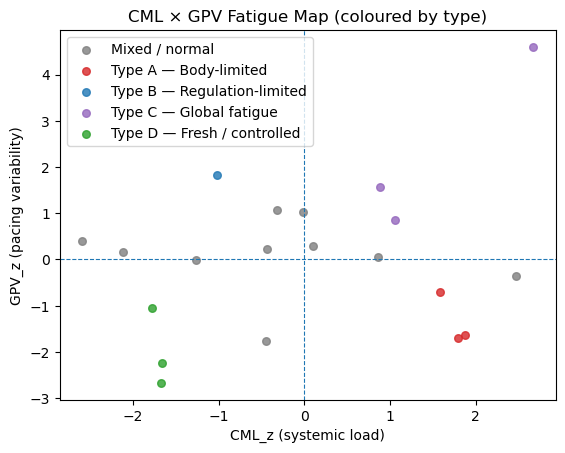

In [38]:
import matplotlib.pyplot as plt
type_colors = {
    "Type A — Body-limited": "tab:red",
    "Type B — Regulation-limited": "tab:blue",
    "Type C — Global fatigue": "tab:purple",
    "Type D — Fresh / controlled": "tab:green",
    "Mixed / normal": "tab:gray",
}

plt.figure()
for label, group in classified_df.groupby("final_label"):
    plt.scatter(
        group["CML_z"],
        group["GPV_z"],
        label=label,
        s=30,
        alpha=0.8,
        c=type_colors.get(label, "tab:gray"),
    )

plt.axvline(0, linestyle="--", linewidth=0.8)
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.xlabel("CML_z (systemic load)")
plt.ylabel("GPV_z (pacing variability)")
plt.title("CML × GPV Fatigue Map (coloured by type)")
plt.legend()
plt.show()


# 3.2 Distribution of fatigue types

In [39]:
classified_df["final_label"].value_counts()

final_label
Mixed / normal                 10
Type D — Fresh / controlled     3
Type C — Global fatigue         3
Type A — Body-limited           3
Type B — Regulation-limited     1
Name: count, dtype: int64

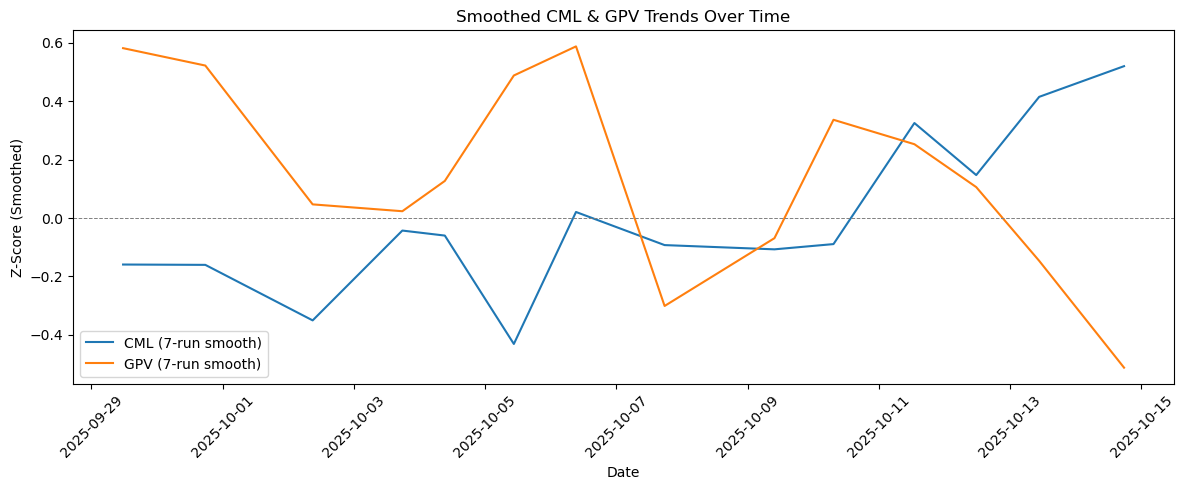

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

classified_df["start_time"] = pd.to_datetime(classified_df["start_time"])
plot_df = classified_df.sort_values("start_time").reset_index(drop=True)

# rolling 7-run smoothing
plot_df["CML_smooth"] = plot_df["CML_z"].rolling(7, center=True).mean()
plot_df["GPV_smooth"] = plot_df["GPV_z"].rolling(7, center=True).mean()

plt.figure(figsize=(12, 5))

plt.plot(plot_df["start_time"], plot_df["CML_smooth"],
         label="CML (7-run smooth)", color="tab:blue")

plt.plot(plot_df["start_time"], plot_df["GPV_smooth"],
         label="GPV (7-run smooth)", color="tab:orange")

plt.axhline(0, color="gray", linestyle="--", linewidth=0.7)
plt.xlabel("Date")
plt.ylabel("Z-Score (Smoothed)")
plt.title("Smoothed CML & GPV Trends Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


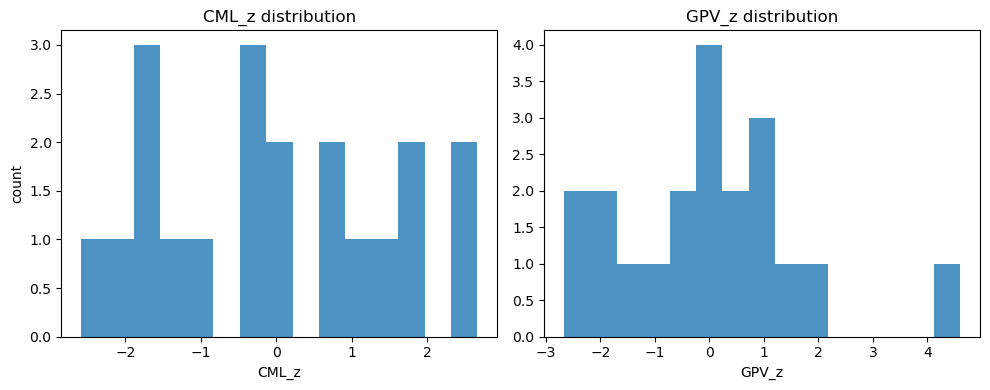

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(features_df["CML_z"], bins=15, alpha=0.8)
plt.title("CML_z distribution")
plt.xlabel("CML_z")
plt.ylabel("count")

plt.subplot(1,2,2)
plt.hist(features_df["GPV_z"], bins=15, alpha=0.8)
plt.title("GPV_z distribution")
plt.xlabel("GPV_z")

plt.tight_layout()
plt.show()


In [44]:
# ensure start_time is datetime
classified_df["start_time"] = pd.to_datetime(classified_df["start_time"])

# date-only version
classified_df["date"] = classified_df["start_time"].dt.date

# sort by time
classified_df = classified_df.sort_values("start_time").reset_index(drop=True)

classified_df[["file", "start_time", "date", "final_label"]].head()


,file,start_time,date,final_label
0,activity_20401950071.tcx,2025-09-16 10:11:45+00:00,2025-09-16,Type D — Fresh / controlled
1,activity_20411248791.tcx,2025-09-17 06:28:58+00:00,2025-09-17,Type C — Global fatigue
2,activity_20432446314.tcx,2025-09-19 07:13:58+00:00,2025-09-19,Mixed / normal
3,activity_20535336288.tcx,2025-09-29 11:35:15+00:00,2025-09-29,Mixed / normal
4,activity_20549513473.tcx,2025-09-30 17:40:09+00:00,2025-09-30,Type A — Body-limited


In [45]:
import numpy as np
import pandas as pd

# --- helper: exponential moving average like TrainingPeaks ---
def ewma(series, halflife_days):
    # decay factor: exp(-ln(2) / halflife)
    alpha = 1 - np.exp(np.log(0.5) / halflife_days)
    return series.ewm(alpha=alpha, adjust=False).mean()

# ensure sorted by time
classified_df = classified_df.sort_values("start_time").reset_index(drop=True)

# --- 1. Create daily time series ---
# Some days have multiple runs → take mean of CML, GPV that day
daily = (
    classified_df.groupby(classified_df["start_time"].dt.date)
    [["CML_z", "GPV_z"]]
    .mean()
    .rename_axis("date")
)

# convert index to timestamp
daily.index = pd.to_datetime(daily.index)

# fill all days between first & last run
all_days = pd.date_range(start=daily.index.min(), end=daily.index.max(), freq="D")
daily = daily.reindex(all_days).fillna(0.0)   # no run = 0 load

# --- 2. Compute ATL (7-day) and CTL (42-day) ---
daily["CML_ATL"] = ewma(daily["CML_z"], halflife_days=7)
daily["CML_CTL"] = ewma(daily["CML_z"], halflife_days=42)
daily["CML_TSB"] = daily["CML_CTL"] - daily["CML_ATL"]

daily["GPV_ATL"] = ewma(daily["GPV_z"], halflife_days=7)
daily["GPV_CTL"] = ewma(daily["GPV_z"], halflife_days=42)
daily["GPV_TSB"] = daily["GPV_CTL"] - daily["GPV_ATL"]

daily.tail()


,CML_z,GPV_z,CML_ATL,CML_CTL,CML_TSB,GPV_ATL,GPV_CTL,GPV_TSB
2025-10-28,0.00000,0.000000,0.011646,-0.826633,-0.838279,-0.014509,-1.086414,-1.071905
2025-10-29,0.00000,0.000000,0.010548,-0.813103,-0.823651,-0.013141,-1.068632,-1.055490
2025-10-30,0.00000,0.000000,0.009554,-0.799794,-0.809348,-0.011902,-1.051140,-1.039238
2025-10-31,0.00000,0.000000,0.008653,-0.786703,-0.795356,-0.010780,-1.033935,-1.023155
2025-11-01,1.78848,-1.699476,0.176449,-0.744552,-0.921001,-0.169984,-1.044829,-0.874844


# How to Interpret Load Dashboard
CML curves = body / metabolic fatigue
ATL spikes → heavy running load
CTL rises → long-term fitness improving
TSB negative → physically tired
TSB positive → recovered
GPV curves = neuromuscular / coordination / mental regulation fatigue
ATL spikes after messy rhythm runs
CTL increases during periods of consistent instability
TSB negative → cognitively/coordination fatigued
TSB positive → brain is “fresh and coordinated”
Combined View = your unique fatigue signature
Example patterns you might see; Pattern	Meaning:
CML-TSB ↓ but GPV-TSB ↑	Body tired, but rhythm/brain fresh
CML-TSB ↑ but GPV-TSB ↓	Body fresh but mentally/neuromuscularly fatigued
Both ↓	Global fatigue (Type C)
Both ↑	Fully fresh

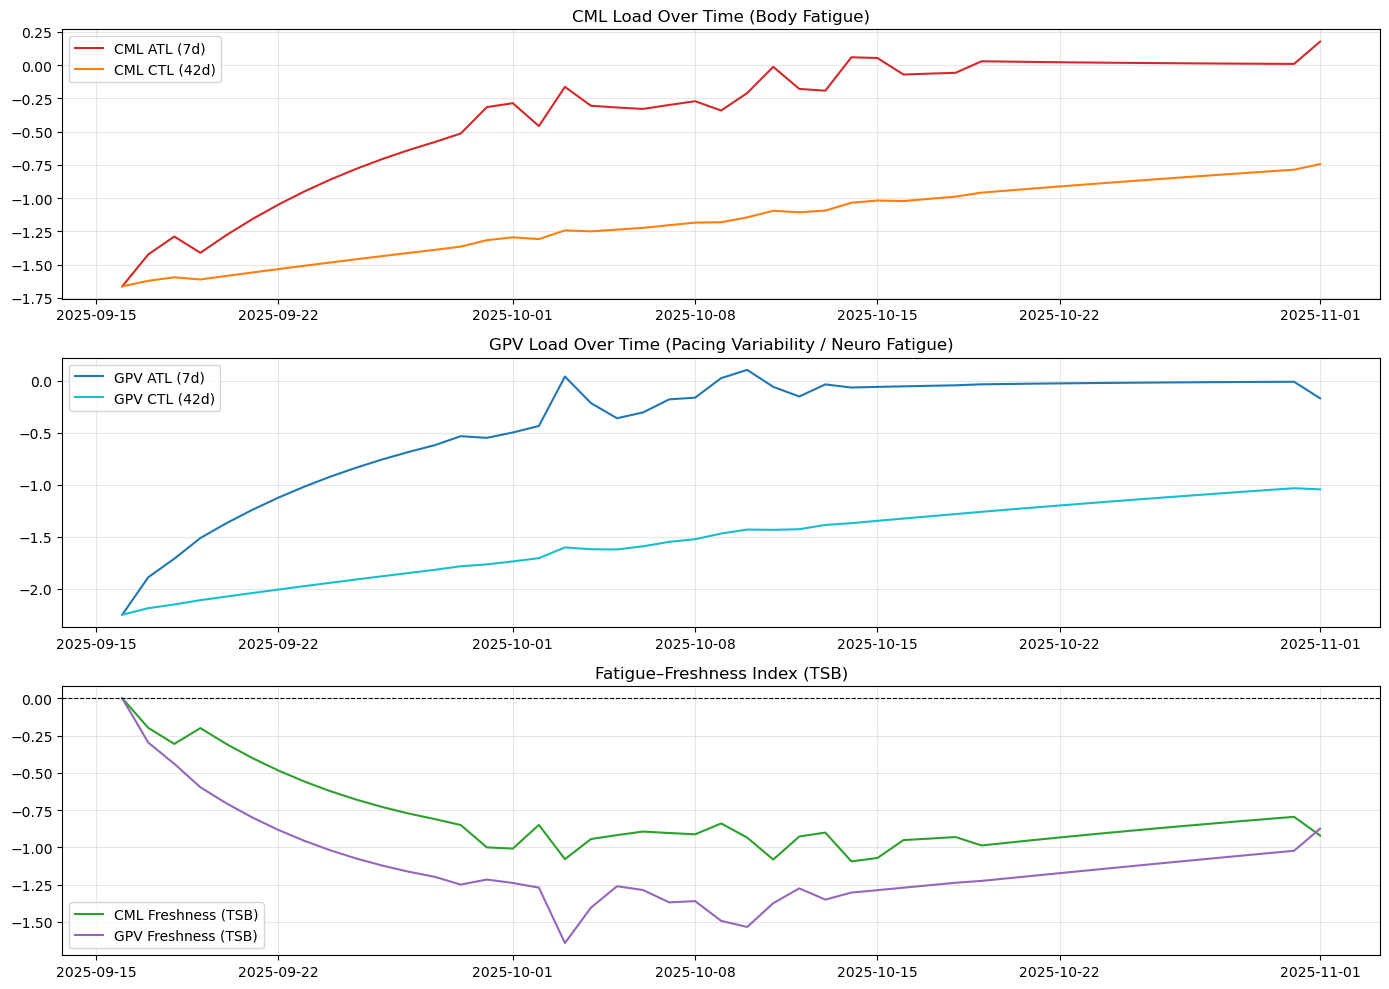

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# --- 1. CML Load (body load) ---
plt.subplot(3,1,1)
plt.plot(daily.index, daily["CML_ATL"], label="CML ATL (7d)", color="tab:red")
plt.plot(daily.index, daily["CML_CTL"], label="CML CTL (42d)", color="tab:orange")
plt.title("CML Load Over Time (Body Fatigue)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 2. GPV Load (coordination/motor/mental fatigue) ---
plt.subplot(3,1,2)
plt.plot(daily.index, daily["GPV_ATL"], label="GPV ATL (7d)", color="tab:blue")
plt.plot(daily.index, daily["GPV_CTL"], label="GPV CTL (42d)", color="tab:cyan")
plt.title("GPV Load Over Time (Pacing Variability / Neuro Fatigue)")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 3. TSB (Freshness) ---
plt.subplot(3,1,3)
plt.plot(daily.index, daily["CML_TSB"], label="CML Freshness (TSB)", color="tab:green")
plt.plot(daily.index, daily["GPV_TSB"], label="GPV Freshness (TSB)", color="tab:purple")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Fatigue–Freshness Index (TSB)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 4 Saving classified runs to CSV


In [47]:
classified_df.to_csv("classified_runs_v1.csv", index=False)